# FunkSVD Hyperparameter Tuning

Grid search over FunkSVD parameters using temporal train/val split.

## 1. Setup

### 1.1. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import json
import pickle
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from src.data.loader import load_ratings
from src.data.splitter import split_temporal
from src.data.adapter import DataAdapter
from src.models.funksvd import FunkSVD
from src.evaluation.metrics import compute_rmse, compute_ranking_metrics

### 1.2 Load and split data

In [2]:
ratings = load_ratings()

train_df, val_df, test_df = split_temporal(
    ratings, 
    train_ratio=0.7, 
    validation_ratio=0.15, 
    test_ratio=0.15,
)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# Convert training data to InteractionData with EXPLICIT ratings
adapter = DataAdapter()
train_data = adapter.to_interactions(train_df)

print(f"Training interactions: {train_data.X_ui.nnz:,}")

Train: 700,118 | Val: 150,081 | Test: 150,010
Training interactions: 700,118


## 2. Tuning

### 2.1 Grid search parameters

In [3]:
param_grid = {
    'n_factors': [10, 20, 50, 100],
    'n_epochs': [20, 50, 100],
    'lr_all': [0.001, 0.005, 0.01],
    'reg_all': [0.01, 0.02, 0.05],
}

# Generate all combinations
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(product(*param_values))

print(f"Total combinations to try: {len(all_combinations)}")

Total combinations to try: 108


### 2.2 Grid search

In [4]:
results = []

# Only evaluate against positive validation interactions
val_positive = val_df[val_df['rating'] >= 4]
val_users = val_positive['user_id'].unique()

print(f"Evaluating on {len(val_positive):,} positive interactions from {len(val_users):,} users")

for combo in tqdm(all_combinations, desc="Grid Search"):
    params = dict(zip(param_names, combo))
    
    model = FunkSVD(**params, random_state=42, verbose=False)
    
    start_time = time.time()
    model.fit(train_data)
    train_time = time.time() - start_time
    
    # Generate recommendations for ranking eval
    recommendations = model.recommend_for_eval(val_users, k=10)
    val_ranking = compute_ranking_metrics(val_positive, recommendations, top_k=10)
    
    result = {
        **params,
        'val_ndcg': val_ranking['ndcg'],
        'val_recall': val_ranking['recall'],
        'train_time_sec': train_time,
    }
    results.append(result)
    
    print(f"{params} -> NDCG: {val_ranking['ndcg']:.4f} ({train_time:.1f}s)")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_ndcg', ascending=False)
results_df.head(10)

,n_factors,n_epochs,lr_all,reg_all,val_ndcg,val_recall,train_time_sec
6,10,20,0.010,0.01,0.039694,0.023852,0.605629
33,20,20,0.010,0.01,0.039118,0.023314,0.904824
18,10,100,0.001,0.01,0.038768,0.022061,1.577938
3,10,20,0.005,0.01,0.038011,0.021624,0.627367
7,10,20,0.010,0.02,0.037997,0.022548,0.618768
12,10,50,0.005,0.01,0.037220,0.022872,0.975076
13,10,50,0.005,0.02,0.036034,0.022002,0.970693
34,20,20,0.010,0.02,0.035765,0.020705,0.893295
60,50,20,0.010,0.01,0.035181,0.020889,1.795811
66,50,50,0.005,0.01,0.034615,0.021873,3.924673


In [5]:
# Best parameters (by NDCG)
best_row = results_df.iloc[0]
best_params = {
    'n_factors': int(best_row['n_factors']),
    'n_epochs': int(best_row['n_epochs']),
    'lr_all': float(best_row['lr_all']),
    'reg_all': float(best_row['reg_all']),
}

print("Best parameters:")
print(json.dumps(best_params, indent=2))
print(f"\nValidation NDCG@10: {best_row['val_ndcg']:.4f}")
print(f"Validation Recall@10: {best_row['val_recall']:.4f}")

Best parameters:
{
  "n_factors": 10,
  "n_epochs": 20,
  "lr_all": 0.01,
  "reg_all": 0.01
}

Validation NDCG@10: 0.0397
Validation Recall@10: 0.0239


## 3. Retrain best model

### 3.1 Retrain best model on train+val, evaluate on test

In [6]:
# Combine train and validation for final model
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_data = adapter.to_interactions(train_val_df)

# Train final model
final_model = FunkSVD(**best_params, random_state=42, verbose=False)
final_model.fit(train_val_data)

# Rating prediction eval (RMSE) - on all test ratings
predictions = final_model.predict(test_df)
test_rmse = compute_rmse(test_df, predictions)

# Ranking eval (NDCG, etc.) - only on positive test interactions
test_positive = test_df[test_df['rating'] >= 4]
test_users = test_positive['user_id'].unique()
recommendations = final_model.recommend_for_eval(test_users, k=10)
ranking_metrics = compute_ranking_metrics(test_positive, recommendations, top_k=10)

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test NDCG@10: {ranking_metrics['ndcg']:.4f}")
print(f"Test MAP@10: {ranking_metrics['map']:.4f}")
print(f"Test Precision@10: {ranking_metrics['precision']:.4f}")
print(f"Test Recall@10: {ranking_metrics['recall']:.4f}")

Test RMSE: 0.8859
Test NDCG@10: 0.0404
Test MAP@10: 0.0184
Test Precision@10: 0.0338
Test Recall@10: 0.0247


### 3.2 Save best model and results

In [7]:
artifacts_dir = Path('../artifacts')
artifacts_dir.mkdir(exist_ok=True)

# Save model
with open(artifacts_dir / 'funksvd_best.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print(f"Model saved to {artifacts_dir / 'funksvd_best.pkl'}")

# Save parameters
params_to_save = {
    'best_params': best_params,
    'val_ndcg': float(best_row['val_ndcg']),
    'test_rmse': float(test_rmse),
    'test_ranking_metrics': ranking_metrics,
}
with open(artifacts_dir / 'funksvd_params.json', 'w') as f:
    json.dump(params_to_save, f, indent=2)
print(f"Parameters saved to {artifacts_dir / 'funksvd_params.json'}")

# Save full results
results_df.to_csv(artifacts_dir / 'funksvd_grid_search.csv', index=False)
print(f"Grid search results saved to {artifacts_dir / 'funksvd_grid_search.csv'}")

Model saved to ../artifacts/funksvd_best.pkl
Parameters saved to ../artifacts/funksvd_params.json
Grid search results saved to ../artifacts/funksvd_grid_search.csv


### 3.3 Visualize results

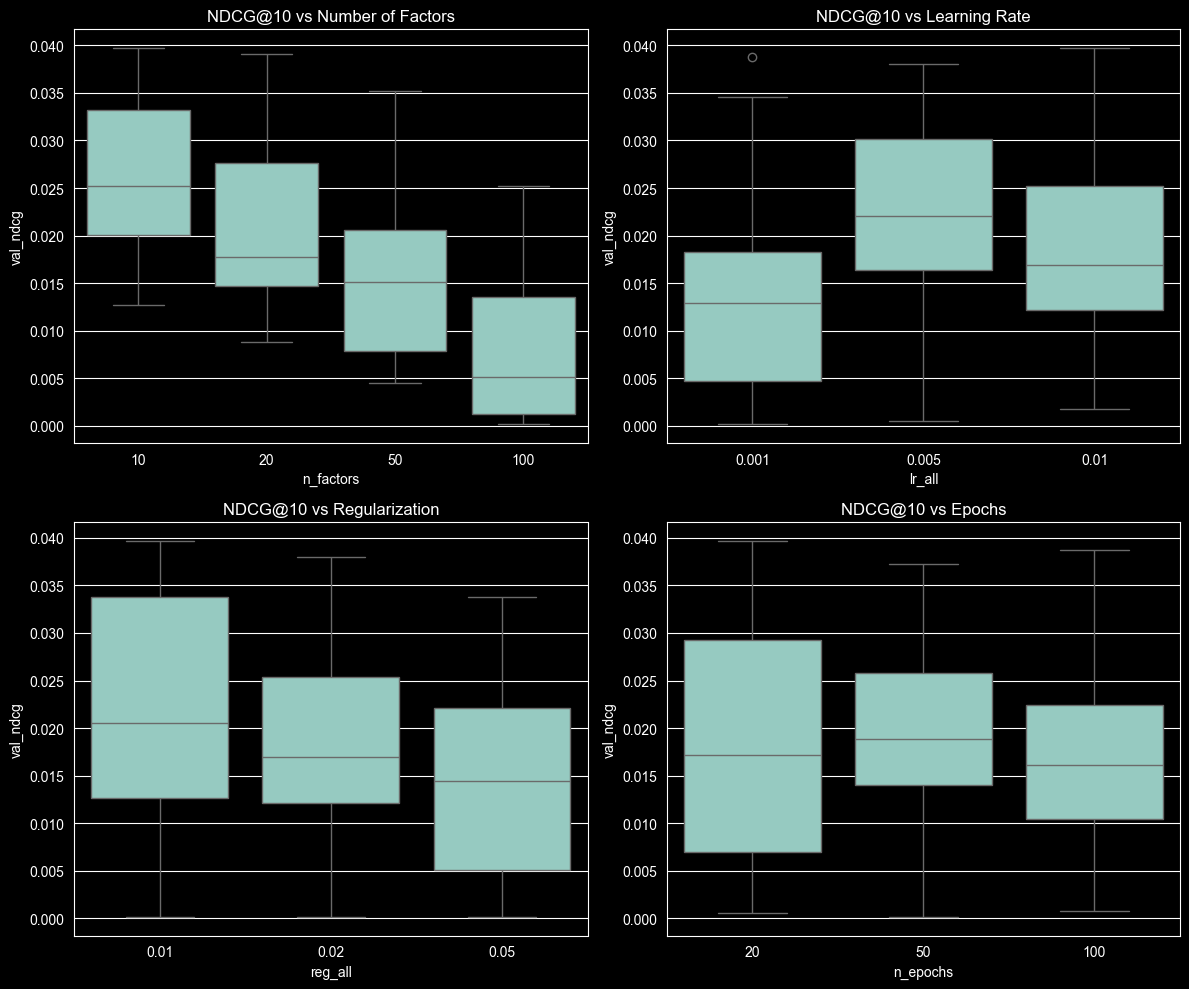

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# NDCG vs n_factors
ax = axes[0, 0]
sns.boxplot(data=results_df, x='n_factors', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Number of Factors')

# NDCG vs learning rate
ax = axes[0, 1]
sns.boxplot(data=results_df, x='lr_all', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Learning Rate')

# NDCG vs regularization
ax = axes[1, 0]
sns.boxplot(data=results_df, x='reg_all', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Regularization')

# NDCG vs epochs
ax = axes[1, 1]
sns.boxplot(data=results_df, x='n_epochs', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Epochs')

plt.tight_layout()
plt.savefig(artifacts_dir / 'funksvd_tuning_plots.png', dpi=150)
plt.show()